In [1]:
!pip install -q transformers datasets accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 89.2 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which 

In [3]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from datasets import load_dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
    TrainingArguments,
    Trainer
)

In [10]:
from datasets import load_dataset

dataset_path = "/kaggle/input/datasets/asaniczka/pc-parts-images-dataset-classification/pc_parts"

dataset = load_dataset(
    "imagefolder",
    data_dir=dataset_path
)

dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)

print(dataset)
print(dataset["train"].features)

Resolving data files:   0%|          | 0/3279 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2623
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 656
    })
})
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['cables', 'case', 'cpu', 'gpu', 'hdd', 'headset', 'keyboard', 'microphone', 'monitor', 'motherboard', 'mouse', 'ram', 'speakers', 'webcam'])}


In [11]:
labels = dataset["train"].features["label"].names
num_labels = len(labels)

id2label = {i: label for i, label in enumerate(labels)}
label2id = {label: i for i, label in enumerate(labels)}

print("Classes:", labels)
print("Number of classes:", num_labels)

Classes: ['cables', 'case', 'cpu', 'gpu', 'hdd', 'headset', 'keyboard', 'microphone', 'monitor', 'motherboard', 'mouse', 'ram', 'speakers', 'webcam']
Number of classes: 14


In [12]:
model_name = "google/vit-base-patch16-224-in21k"

processor = AutoImageProcessor.from_pretrained(model_name)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


In [13]:
def transform(example):
    image = example["image"].convert("RGB")
    inputs = processor(image, return_tensors="pt")
    example["pixel_values"] = inputs["pixel_values"].squeeze(0)
    return example

dataset = dataset.map(transform)

dataset = dataset.remove_columns(["image"])
dataset.set_format("torch")

Map:   0%|          | 0/2623 [00:00<?, ? examples/s]

Map:   0%|          | 0/656 [00:00<?, ? examples/s]

In [14]:
model = AutoModelForImageClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [16]:
training_args = TrainingArguments(
    output_dir="/kaggle/working/vit-pc-parts-classifier",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    remove_unused_columns=False,
    report_to="none"
)

In [17]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=processor,
    compute_metrics=compute_metrics
)

In [18]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.913984,1.937430,0.742378,0.798366,0.742378,0.734665
2,1.514358,1.473155,0.789634,0.816099,0.789634,0.783981
3,1.120822,1.257991,0.803354,0.822408,0.803354,0.803921
4,0.956562,1.155182,0.807927,0.821737,0.807927,0.809486
5,0.842342,1.127247,0.809451,0.822209,0.809451,0.810849


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=820, training_loss=1.3810909899269663, metrics={'train_runtime': 499.7699, 'train_samples_per_second': 26.242, 'train_steps_per_second': 1.641, 'total_flos': 1.016416749901271e+18, 'train_loss': 1.3810909899269663, 'epoch': 5.0})

In [19]:
trainer.evaluate()

{'eval_loss': 1.1272472143173218,
 'eval_accuracy': 0.8094512195121951,
 'eval_precision': 0.8222094416831546,
 'eval_recall': 0.8094512195121951,
 'eval_f1': 0.8108490600760144,
 'eval_runtime': 11.5993,
 'eval_samples_per_second': 56.555,
 'eval_steps_per_second': 3.535,
 'epoch': 5.0}

Resolving data files:   0%|          | 0/3279 [00:00<?, ?it/s]

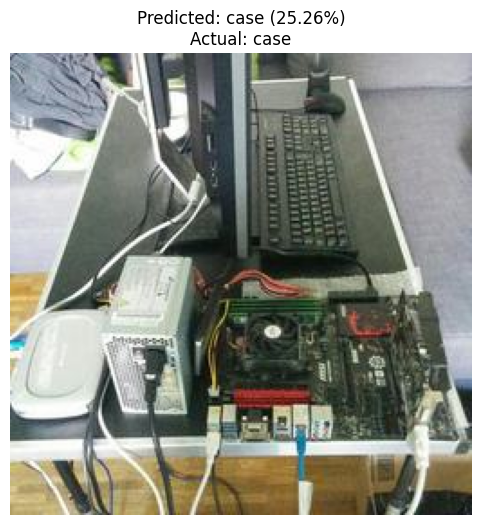

In [21]:
import torch
import matplotlib.pyplot as plt
from PIL import Image

raw_dataset = load_dataset("imagefolder", data_dir=dataset_path)
raw_dataset = raw_dataset["train"].train_test_split(test_size=0.2, seed=42)

sample_raw = raw_dataset["test"][0]
image = sample_raw["image"].convert("RGB")

inputs = processor(image, return_tensors="pt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)
    predicted_id = probs.argmax(-1).item()
    confidence = probs[0][predicted_id].item() * 100

predicted_class = id2label[predicted_id]
actual_class = id2label[sample_raw["label"]]

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)\nActual: {actual_class}")
plt.axis("off")
plt.show()